## After trial and error, this should be the more successful results analysis notebook

In [1]:
import pickle
import numpy as np
import pandas as pd
from pyhere import here
import matplotlib.pyplot as plt
from ratio_function import RatioGenerator, LogRatioGenerator
import itertools
from plotnine import *
from sklearn.model_selection import train_test_split
from sklearn import set_config
from skopt import BayesSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from xgboost import plot_importance
from sklearn.svm import SVR
from skopt.space import Categorical, Real, Integer
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import cross_val_score, cross_validate, KFold
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.base import clone
from sklearn.inspection import permutation_importance

set_config(transform_output="pandas")

Loading all the reuquired stuff

In [ ]:
# with open(here("pipeline/spaces", "space_list.pkl"), "rb") as file:
#     search_space_list = pickle.load(file)

# with open(here("pipeline/spaces", "model_list.pkl"), "rb") as file2:
#     model_list = pickle.load(file2)

phot = pd.read_csv(here("data/cleaned", "MIRION_cleaned_everything.csv"))

flux_cols = ['F8', 'F12', 'F24', 'F70', 'F160', 'F250', 'F350', 'F500', 'F870', 'F1100']

model_pipe = Pipeline([
        ('impute', SimpleImputer()),
        ('ratio', RatioGenerator(cols=flux_cols)),
        ('scale', RobustScaler()),
        ('model', 'passthrough')
    ])

remove_properties = ['LRATIO', 'T_BOL', 'LM', 'L_BOL', 'MASS', 'DIAM', 'SURF_DENS', 'YB', 'TEMP']

# remove the reponses to contain only the physical properties
X = phot.drop(columns=remove_properties)

# will end up as the final dataframe that contains the results in a table-like format
results = {
    "RESP": [],
    "log": [],
    "CV_score": [],
    "test_score": [],
    "test_r2": [],
    "model_type": []
}

# Bolometric luminosity

In [ ]:
with open(here("models/full_models/6-20-26_best_skopt_models", "L_BOL_results.pkl"), 'rb') as file:
    lbol_results = pickle.load(file)

print(lbol_results['cat_log_CV'])
# print(lbol_results['xgb_log_CV'])
# print(lbol_results['rf_log_CV'])
# print(lbol_results['tree_log_CV'])
# print(lbol_results['svr_log_CV'])
print(lbol_results['cat_log_params'])

0.4231401644192835
OrderedDict({'impute': 'passthrough', 'model__bagging_temperature': 0.0, 'model__border_count': 255, 'model__colsample_bylevel': 0.43274901277331335, 'model__depth': 5, 'model__grow_policy': 'SymmetricTree', 'model__iterations': 2659, 'model__l2_leaf_reg': 0.001, 'model__learning_rate': 0.02371580651393871, 'model__min_data_in_leaf': 1, 'model__random_strength': 10.0, 'ratio': RatioGenerator(cols=['F8', 'F12', 'F24', 'F70', 'F160', 'F250', 'F350', 'F500',
                     'F870', 'F1100']), 'scale': StandardScaler()})


In [4]:
y_log_lbol = np.log(phot['L_BOL'])
lbol_X_train, lbol_X_test, lbol_y_train, lbol_y_test = train_test_split(X, y_log_lbol, test_size = 0.2, random_state=2026)

lbol_model_pipe = clone(model_pipe)
lbol_model = CatBoostRegressor(random_state=2026, verbose=0, thread_count=-1, loss_function='RMSE')
best_lbol_model = lbol_model_pipe.set_params(model=lbol_model)
best_lbol_model.set_params(**lbol_results['cat_log_params'])

best_lbol_model.fit(lbol_X_train, lbol_y_train)
lbol_y_preds = best_lbol_model.predict(lbol_X_test)
lbol_rmse = root_mean_squared_error(lbol_y_test, lbol_y_preds)
lbol_r2 = r2_score(lbol_y_test, lbol_y_preds)
print(f"Training set RMSE (log scale) for Bolometric luminosity is {lbol_results['cat_log_CV']:.4f}.")
print(f"Test set RMSE (log scale) for Bolometric luminosity is {lbol_rmse:.4f}.")
print("\n")
print(f"Test set r squared for Bolometric Luminosity (log scale) is {lbol_r2:.4f}.")

results["RESP"].append('L_BOL')
results['log'].append(True)
results['CV_score'].append(lbol_results['cat_log_CV'])
results['model_type'].append('Catboost')
results['test_score'].append(lbol_rmse)
results['test_r2'].append(lbol_r2)

Training set RMSE (log scale) for Bolometric luminosity is 0.4231.
Test set RMSE (log scale) for Bolometric luminosity is 0.4073.


Test set r squared for Bolometric Luminosity (log scale) is 0.9683.


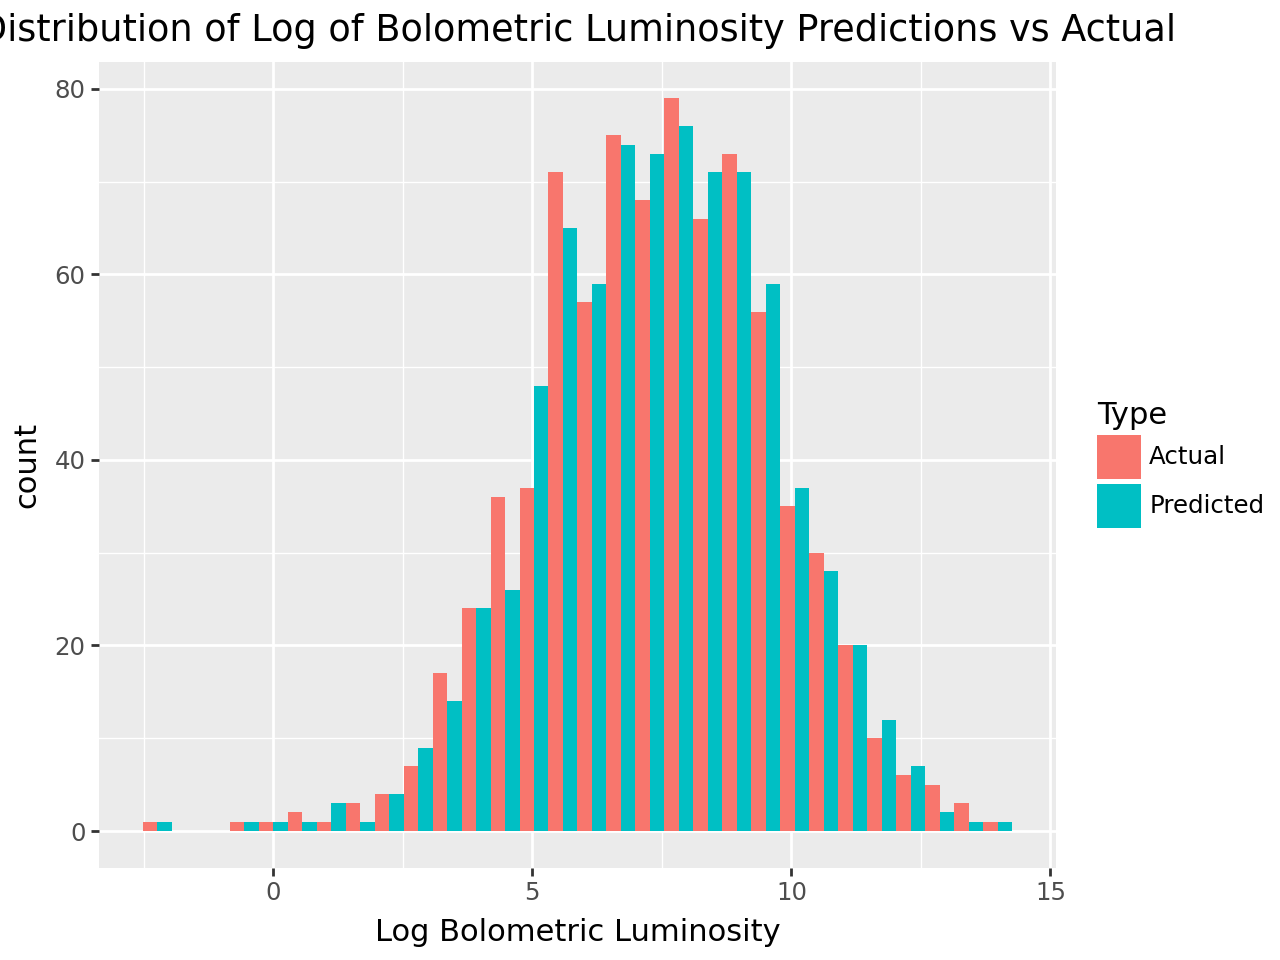

In [7]:
lbol_predictions_df = lbol_y_test.copy()
lbol_predictions_df = pd.DataFrame(lbol_predictions_df)
lbol_predictions_df['y_preds'] = lbol_y_preds
lbol_predictions_df.head()

lbol_melted = pd.melt(lbol_predictions_df, value_vars=['L_BOL', 'y_preds'], var_name='Variable', value_name='Value')
(
    ggplot(lbol_melted, aes(x='Value', fill='Variable')) +
    geom_histogram(bins=30, position='dodge') +
    labs(title='Distribution of Log of Bolometric Luminosity Predictions vs Actual', x='Log Bolometric Luminosity') +
    scale_fill_discrete(labels=['Actual', 'Predicted'], name='Type')
)

## doesn't seem very useful because log scale hides the major differences it seems


c:\Users\alexe\miniforge3\envs\math4025\Lib\site-packages\plotnine\stats\stat_bin.py:112: PlotnineWarning: 'stat_bin()' using 'bins = 49'. Pick better value with 'binwidth'.


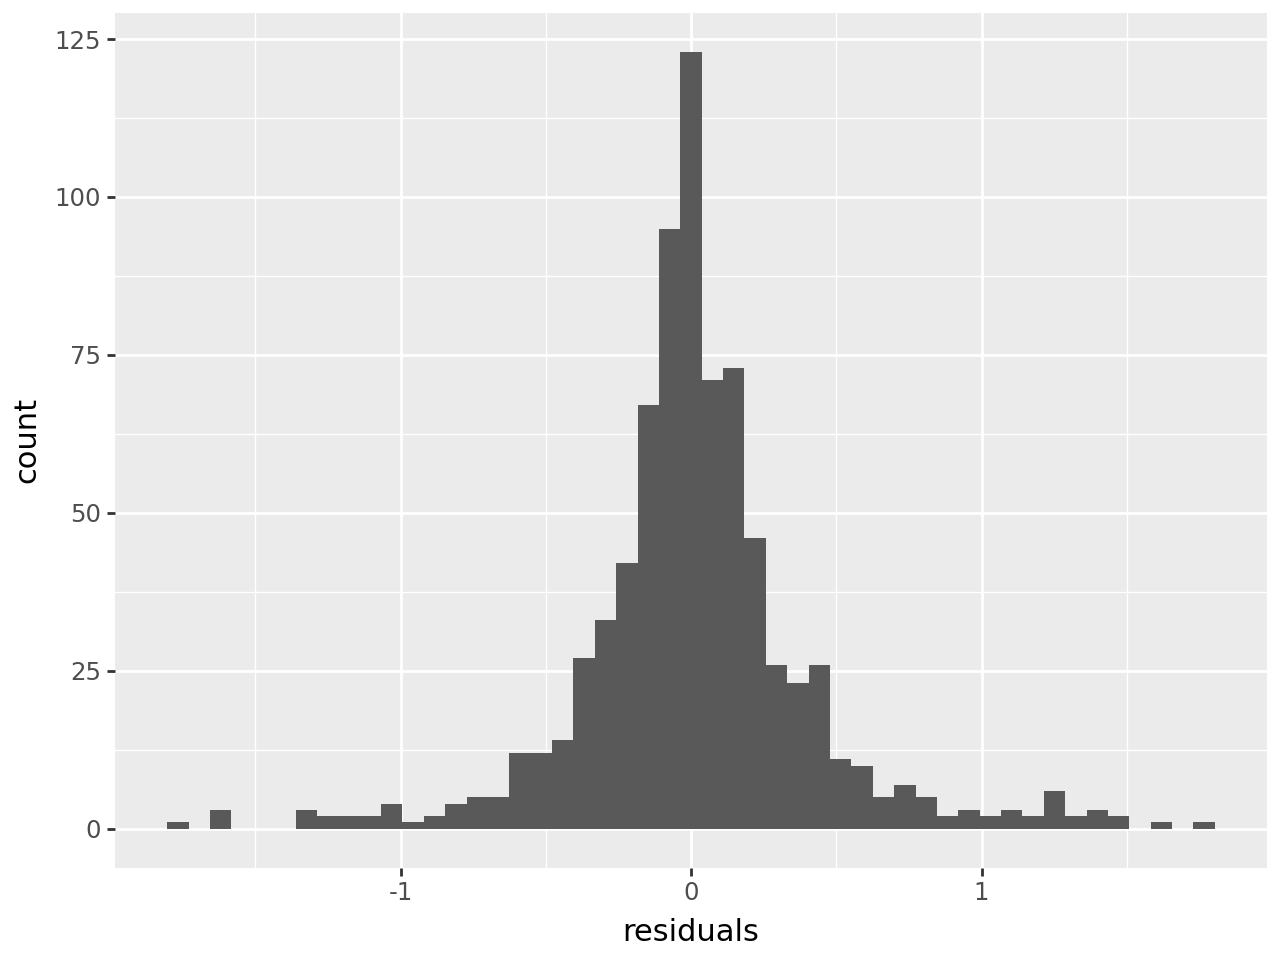

In [9]:
lbol_predictions_df['residuals'] = lbol_predictions_df['y_preds'] - lbol_predictions_df['L_BOL']

(
    ggplot(lbol_predictions_df, aes(x='residuals')) +
    geom_histogram()
)

MDI Feature Importances

In [9]:
# lbol_importances = best_lbol_model.named_steps['model'].feature_importances_
# lbol_imp_df = pd.DataFrame({
#     'Feature': best_lbol_model.named_steps['model'].feature_names_,
#     'Importance': lbol_importances
# }).sort_values(by='Importance', ascending=False)
# print(lbol_imp_df.head())
# lbol_imp_df['Feature'] = pd.Categorical(lbol_imp_df['Feature'], categories=lbol_imp_df['Feature'].unique())
# (
#     ggplot(lbol_imp_df.head(), aes(x='Feature', y='Importance')) +
#     geom_col() +
#     coord_flip()
# )

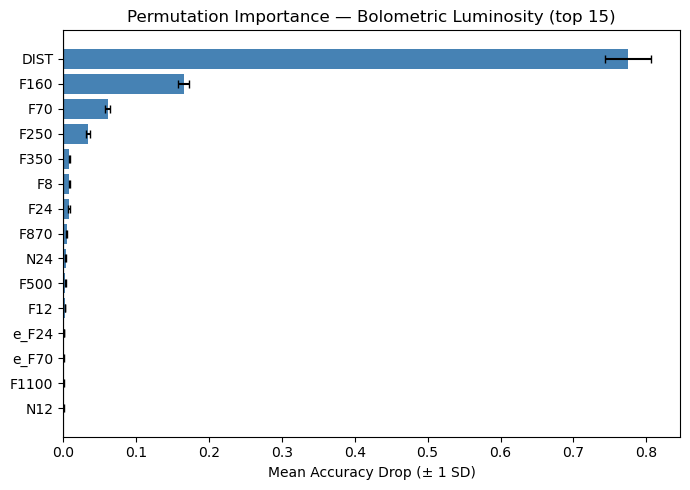

In [6]:
perm_lbol = permutation_importance(
    best_lbol_model, lbol_X_test, lbol_y_test,
    n_repeats=10, random_state=2026, n_jobs=-1
)

perm_lbol_df = (pd.DataFrame({
    'feature': lbol_X_test.columns,
    'mean': perm_lbol.importances_mean,
    'std':  perm_lbol.importances_std
}).sort_values('mean', ascending=False).head(15))

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(perm_lbol_df['feature'][::-1], perm_lbol_df['mean'][::-1],
        xerr=perm_lbol_df['std'][::-1], color='steelblue', capsize=3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mean Accuracy Drop (± 1 SD)')
ax.set_title('Permutation Importance — Bolometric Luminosity (top 15)')
plt.tight_layout()
plt.show()

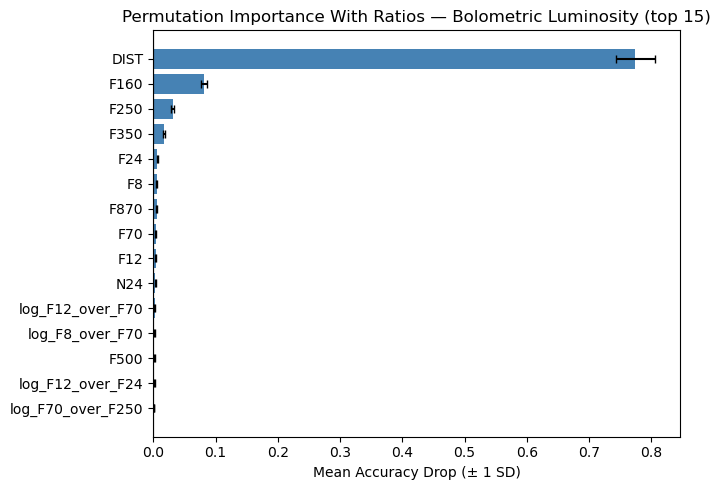

In [7]:
phot_for_perm = X.copy()
for top, bottom in itertools.combinations(flux_cols, 2):
    new_col_name = f"log_{top}_over_{bottom}"
    phot_for_perm[new_col_name] = np.log(phot_for_perm[top] / phot_for_perm[bottom])
perm_lbol_X_train, perm_lbol_X_test, perm_lbol_y_train, perm_lbol_y_test = train_test_split(phot_for_perm, y_log_lbol, test_size = 0.2, random_state=2026)
perm_lbol_pipe = Pipeline([
    ('impute', SimpleImputer()),
    ('scale', RobustScaler()),
    ('model', CatBoostRegressor(random_state=2026, verbose=0, thread_count=-1, loss_function='RMSE'))
])
if 'ratio' in lbol_results['cat_log_params']:
    del lbol_results['cat_log_params']['ratio']
perm_lbol_pipe.set_params(**lbol_results['cat_log_params'])
perm_lbol_pipe.fit(perm_lbol_X_train, perm_lbol_y_train)
perm_lbol_with_ratios = permutation_importance(
    perm_lbol_pipe, perm_lbol_X_test, perm_lbol_y_test,
    n_repeats=10, random_state=2026, n_jobs=-1
)
perm_lbol_ratios_df = (pd.DataFrame({
    'feature': perm_lbol_X_test.columns,
    'mean': perm_lbol_with_ratios.importances_mean,
    'std':  perm_lbol_with_ratios.importances_std
}).sort_values('mean', ascending=False).head(15))

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(perm_lbol_ratios_df['feature'][::-1], perm_lbol_ratios_df['mean'][::-1],
        xerr=perm_lbol_ratios_df['std'][::-1], color='steelblue', capsize=3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mean Accuracy Drop (± 1 SD)')
ax.set_title('Permutation Importance With Ratios — Bolometric Luminosity (top 15)')
plt.tight_layout()
plt.show()

# Diameter results

In [ ]:
with open(here("models/full_models/6-20-26_best_skopt_models", "DIAM_results.pkl"), 'rb') as file:
    diam_results = pickle.load(file)

print(diam_results['cat_log_CV'])
# print(diam_results['xgb_log_CV'])
# print(diam_results['rf_log_CV'])
# print(diam_results['tree_log_CV'])
# print(diam_results['svr_log_CV'])
print(diam_results['cat_log_params'])

0.2661171158527679
OrderedDict({'impute': 'passthrough', 'model__bagging_temperature': 9.674143188415915, 'model__border_count': 227, 'model__colsample_bylevel': 0.7643308391618173, 'model__depth': 9, 'model__grow_policy': 'Lossguide', 'model__iterations': 3000, 'model__l2_leaf_reg': 0.001, 'model__learning_rate': 0.006054862842745563, 'model__min_data_in_leaf': 5, 'model__random_strength': 10.0, 'ratio': LogRatioGenerator(cols=['F8', 'F12', 'F24', 'F70', 'F160', 'F250', 'F350',
                        'F500', 'F870', 'F1100']), 'scale': StandardScaler()})


In [9]:
y_log_diam = np.log(phot['DIAM'])

diam_X_train, diam_X_test, diam_y_train, diam_y_test = train_test_split(X, y_log_diam, test_size = 0.2, random_state=2026)

diam_model_pipe = clone(model_pipe)
diam_model = CatBoostRegressor(random_state=2026, verbose=0, thread_count=-1, loss_function='RMSE')
best_diam_model = diam_model_pipe.set_params(model=diam_model)
best_diam_model.set_params(**diam_results['cat_log_params'])

best_diam_model.fit(diam_X_train, diam_y_train)
diam_y_preds = best_diam_model.predict(diam_X_test)
diam_rmse = root_mean_squared_error(diam_y_test, diam_y_preds)
diam_r2 = r2_score(diam_y_test, diam_y_preds)
print(f"Training set RMSE (log scale) for Diameter is {diam_results['cat_log_CV']:.4f}.")
print(f"Test set RMSE (log scale) for Diameter is {diam_rmse:.4f}.")
print("\n")
print(f"Test set r squared for Diameter (log scale) is {diam_r2:.4f}.")

results["RESP"].append('DIAM')
results['log'].append(True)
results['CV_score'].append(diam_results['cat_log_CV'])
results['model_type'].append('Catboost')
results['test_score'].append(diam_rmse)
results['test_r2'].append(diam_r2)

Training set RMSE (log scale) for Diameter is 0.2661.
Test set RMSE (log scale) for Diameter is 0.2571.


Test set r squared for Diameter (log scale) is 0.8924.


In [14]:
# diam_importances = best_diam_model.named_steps['model'].feature_importances_
# diam_imp_df = pd.DataFrame({
#     'Feature': best_diam_model.named_steps['model'].feature_names_,
#     'Importance': diam_importances
# }).sort_values(by='Importance', ascending=False)
# print(diam_imp_df.head())
# diam_imp_df['Feature'] = pd.Categorical(diam_imp_df['Feature'], categories=diam_imp_df['Feature'].unique())
# (
#     ggplot(diam_imp_df.head(), aes(x='Feature', y='Importance')) +
#     geom_col()
# )

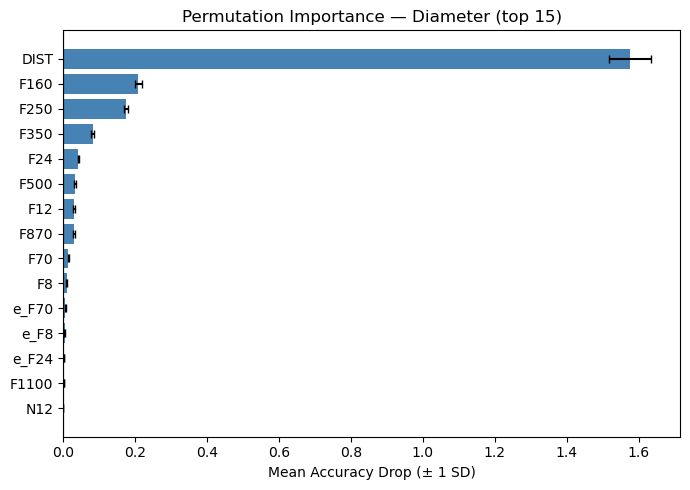

In [15]:
perm_diam = permutation_importance(
    best_diam_model, diam_X_test, diam_y_test,
    n_repeats=10, random_state=2026, n_jobs=-1
)

perm_diam_df = (pd.DataFrame({
    'feature': diam_X_test.columns,
    'mean': perm_diam.importances_mean,
    'std':  perm_diam.importances_std
}).sort_values('mean', ascending=False).head(15))

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(perm_diam_df['feature'][::-1], perm_diam_df['mean'][::-1],
        xerr=perm_diam_df['std'][::-1], color='steelblue', capsize=3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mean Accuracy Drop (± 1 SD)')
ax.set_title('Permutation Importance — Diameter (top 15)')
plt.tight_layout()
plt.show()

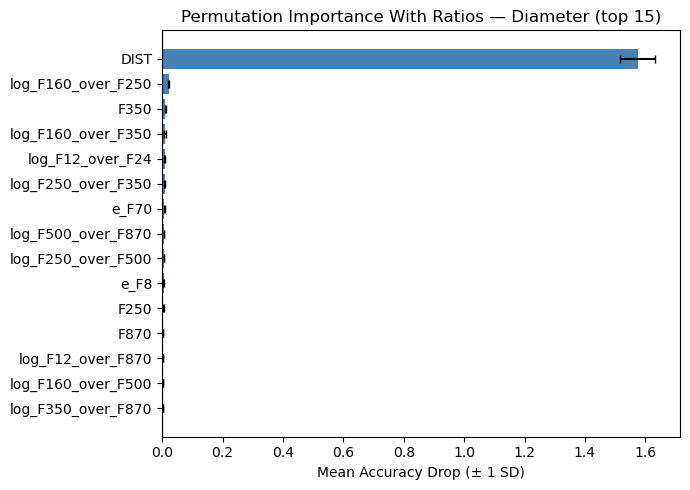

In [10]:
phot_for_perm = X.copy()
for top, bottom in itertools.combinations(flux_cols, 2):
    new_col_name = f"log_{top}_over_{bottom}"
    phot_for_perm[new_col_name] = np.log(phot_for_perm[top] / phot_for_perm[bottom])
perm_diam_X_train, perm_diam_X_test, perm_diam_y_train, perm_diam_y_test = train_test_split(phot_for_perm, y_log_diam, test_size = 0.2, random_state=2026)
perm_diam_pipe = Pipeline([
    ('impute', SimpleImputer()),
    ('scale', RobustScaler()),
    ('model', CatBoostRegressor(random_state=2026, verbose=0, thread_count=-1, loss_function='RMSE'))
])
if 'ratio' in diam_results['cat_log_params']:
    del diam_results['cat_log_params']['ratio']
perm_diam_pipe.set_params(**diam_results['cat_log_params'])
perm_diam_pipe.fit(perm_diam_X_train, perm_diam_y_train)
perm_diam_with_ratios = permutation_importance(
    perm_diam_pipe, perm_diam_X_test, perm_diam_y_test,
    n_repeats=10, random_state=2026, n_jobs=-1
)
perm_diam_ratios_df = (pd.DataFrame({
    'feature': perm_diam_X_test.columns,
    'mean': perm_diam_with_ratios.importances_mean,
    'std':  perm_diam_with_ratios.importances_std
}).sort_values('mean', ascending=False).head(15))

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(perm_diam_ratios_df['feature'][::-1], perm_diam_ratios_df['mean'][::-1],
        xerr=perm_diam_ratios_df['std'][::-1], color='steelblue', capsize=3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mean Accuracy Drop (± 1 SD)')
ax.set_title('Permutation Importance With Ratios — Diameter (top 15)')
plt.tight_layout()
plt.show()

# Mass

In [ ]:
with open(here("models/full_models/6-20-26_best_skopt_models", "MASS_results.pkl"), 'rb') as file:
    mass_results = pickle.load(file)

print(mass_results['cat_log_CV'])
# print(mass_results['xgb_log_CV'])
# print(mass_results['rf_log_CV'])
# print(mass_results['tree_log_CV'])
# print(mass_results['svr_log_CV'])
print(mass_results['cat_log_params'])

0.28988611506162754
OrderedDict({'impute': 'passthrough', 'model__bagging_temperature': 5.952437356709979, 'model__border_count': 255, 'model__colsample_bylevel': 0.8151061525134667, 'model__depth': 6, 'model__grow_policy': 'SymmetricTree', 'model__iterations': 1168, 'model__l2_leaf_reg': 0.0769799456158058, 'model__learning_rate': 0.024173922047660872, 'model__min_data_in_leaf': 69, 'model__random_strength': 0.5427497837727402, 'ratio': LogRatioGenerator(cols=['F8', 'F12', 'F24', 'F70', 'F160', 'F250', 'F350',
                        'F500', 'F870', 'F1100']), 'scale': StandardScaler()})


In [12]:
y_log_mass = np.log(phot['MASS'])

mass_X_train, mass_X_test, mass_y_train, mass_y_test = train_test_split(X, y_log_mass, test_size = 0.2, random_state=2026)

mass_model_pipe = clone(model_pipe)
mass_model = CatBoostRegressor(random_state=2026, verbose=0, thread_count=-1, loss_function='RMSE')
best_mass_model = mass_model_pipe.set_params(model=mass_model)
best_mass_model.set_params(**mass_results['cat_log_params'])

best_mass_model.fit(mass_X_train, mass_y_train)
mass_y_preds = best_mass_model.predict(mass_X_test)
mass_rmse = root_mean_squared_error(mass_y_test, mass_y_preds)
mass_r2 = r2_score(mass_y_test, mass_y_preds)
print(f"Training set RMSE (log scale) for mass is {mass_results['cat_log_CV']:.4f}.")
print(f"Test set RMSE (log scale) for mass is {mass_rmse:.4f}.")
print("\n")
print(f"Test set r squared (log scale) for mass is {mass_r2:.4f}.")

results["RESP"].append('MASS')
results['log'].append(True)
results['CV_score'].append(mass_results['cat_log_CV'])
results['model_type'].append('Catboost')
results['test_score'].append(mass_rmse)
results['test_r2'].append(mass_r2)

Training set RMSE (log scale) for mass is 0.2899.
Test set RMSE (log scale) for mass is 0.2901.


Test set r squared (log scale) for mass is 0.9779.


In [19]:
# mass_importances = best_mass_model.named_steps['model'].feature_importances_
# mass_imp_df = pd.DataFrame({
#     'Feature': best_mass_model.named_steps['model'].feature_names_,
#     'Importance': mass_importances
# }).sort_values(by='Importance', ascending=False)
# print(mass_imp_df.head())
# mass_imp_df['Feature'] = pd.Categorical(mass_imp_df['Feature'], categories=mass_imp_df['Feature'].unique())
# (
#     ggplot(mass_imp_df.head(6), aes(x='Feature', y='Importance')) +
#     geom_col()
# )

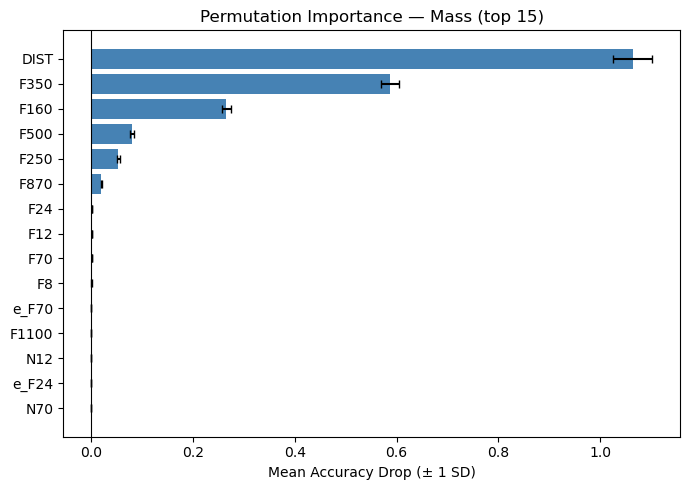

In [20]:
perm_mass = permutation_importance(
    best_mass_model, mass_X_test, mass_y_test,
    n_repeats=10, random_state=2026, n_jobs=-1
)

perm_mass_df = (pd.DataFrame({
    'feature': mass_X_test.columns,
    'mean': perm_mass.importances_mean,
    'std':  perm_mass.importances_std
}).sort_values('mean', ascending=False).head(15))

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(perm_mass_df['feature'][::-1], perm_mass_df['mean'][::-1],
        xerr=perm_mass_df['std'][::-1], color='steelblue', capsize=3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mean Accuracy Drop (± 1 SD)')
ax.set_title('Permutation Importance — Mass (top 15)')
plt.tight_layout()
plt.show()

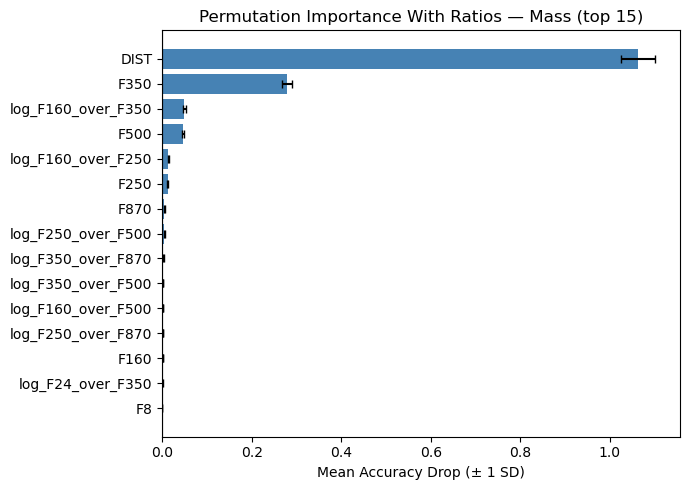

In [13]:
phot_for_perm = X.copy()
for top, bottom in itertools.combinations(flux_cols, 2):
    new_col_name = f"log_{top}_over_{bottom}"
    phot_for_perm[new_col_name] = np.log(phot_for_perm[top] / phot_for_perm[bottom])
perm_mass_X_train, perm_mass_X_test, perm_mass_y_train, perm_mass_y_test = train_test_split(phot_for_perm, y_log_mass, test_size = 0.2, random_state=2026)
perm_mass_pipe = Pipeline([
    ('impute', SimpleImputer()),
    ('scale', RobustScaler()),
    ('model', CatBoostRegressor(random_state=2026, verbose=0, thread_count=-1, loss_function='RMSE'))
])
if 'ratio' in mass_results['cat_log_params']:
    del mass_results['cat_log_params']['ratio']
perm_mass_pipe.set_params(**mass_results['cat_log_params'])
perm_mass_pipe.fit(perm_mass_X_train, perm_mass_y_train)
perm_mass_with_ratios = permutation_importance(
    perm_mass_pipe, perm_mass_X_test, perm_mass_y_test,
    n_repeats=10, random_state=2026, n_jobs=-1
)
perm_mass_ratios_df = (pd.DataFrame({
    'feature': perm_mass_X_test.columns,
    'mean': perm_mass_with_ratios.importances_mean,
    'std':  perm_mass_with_ratios.importances_std
}).sort_values('mean', ascending=False).head(15))

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(perm_mass_ratios_df['feature'][::-1], perm_mass_ratios_df['mean'][::-1],
        xerr=perm_mass_ratios_df['std'][::-1], color='steelblue', capsize=3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mean Accuracy Drop (± 1 SD)')
ax.set_title('Permutation Importance With Ratios — Mass (top 15)')
plt.tight_layout()
plt.show()

# Temp

In [ ]:
with open(here("models/full_models/6-20-26_best_skopt_models", "TEMP_results.pkl"), 'rb') as file:
    temp_results = pickle.load(file)

print(temp_results['cat_CV'])
# print(temp_results['xgb_CV'])
# print(temp_results['rf_CV'])
# print(temp_results['tree_CV'])
# print(temp_results['svr_CV'])
print(temp_results['xgb_params'])

1.3050603257727187
OrderedDict({'impute': 'passthrough', 'model__colsample_bylevel': 0.5, 'model__colsample_bytree': 0.801815724301408, 'model__gamma': 2.674781769502737e-08, 'model__learning_rate': 0.007033040108829162, 'model__max_depth': 10, 'model__min_child_weight': 7, 'model__n_estimators': 797, 'model__reg_alpha': 0.07077167419493458, 'model__reg_lambda': 0.0004663018608029879, 'model__subsample': 0.6221949843956174, 'ratio': LogRatioGenerator(cols=['F8', 'F12', 'F24', 'F70', 'F160', 'F250', 'F350',
                        'F500', 'F870', 'F1100']), 'scale': StandardScaler()})


In [15]:
y_temp = (phot['TEMP'])

temp_X_train, temp_X_test, temp_y_train, temp_y_test = train_test_split(X, y_temp, test_size = 0.2, random_state=2026)

temp_model_pipe = clone(model_pipe)
temp_model = CatBoostRegressor(random_state=2026, verbose=0, thread_count=-1, loss_function='RMSE')
best_temp_model = temp_model_pipe.set_params(model=temp_model)
best_temp_model.set_params(**temp_results['cat_params'])

best_temp_model.fit(temp_X_train, temp_y_train)
temp_y_preds = best_temp_model.predict(temp_X_test)
temp_rmse = root_mean_squared_error(temp_y_test, temp_y_preds)
temp_r2 = r2_score(temp_y_test, temp_y_preds)
print(f"Training set RMSE for temp is {temp_results['cat_CV']:.4f}.")
print(f"Test set RMSE for temp is {temp_rmse:.4f}.")
print("\n")
print(f"Test set r squared for temp is {temp_r2:.4f}.")

results["RESP"].append('TEMP')
results['log'].append(False)
results['CV_score'].append(temp_results['cat_CV'])
results['model_type'].append('Catboost')
results['test_score'].append(temp_rmse)
results['test_r2'].append(temp_r2)

Training set RMSE for temp is 1.3051.
Test set RMSE for temp is 1.6125.


Test set r squared for temp is 0.8871.


In [24]:
# temp_importances = best_temp_model.named_steps['model'].feature_importances_
# temp_imp_df = pd.DataFrame({
#     'Feature': best_temp_model.named_steps['model'].feature_names_,
#     'Importance': temp_importances
# }).sort_values(by='Importance', ascending=False)
# print(temp_imp_df.head())
# temp_imp_df['Feature'] = pd.Categorical(temp_imp_df['Feature'], categories=temp_imp_df['Feature'].unique())
# (
#     ggplot(temp_imp_df.head(6), aes(x='Feature', y='Importance')) +
#     geom_col()
# )

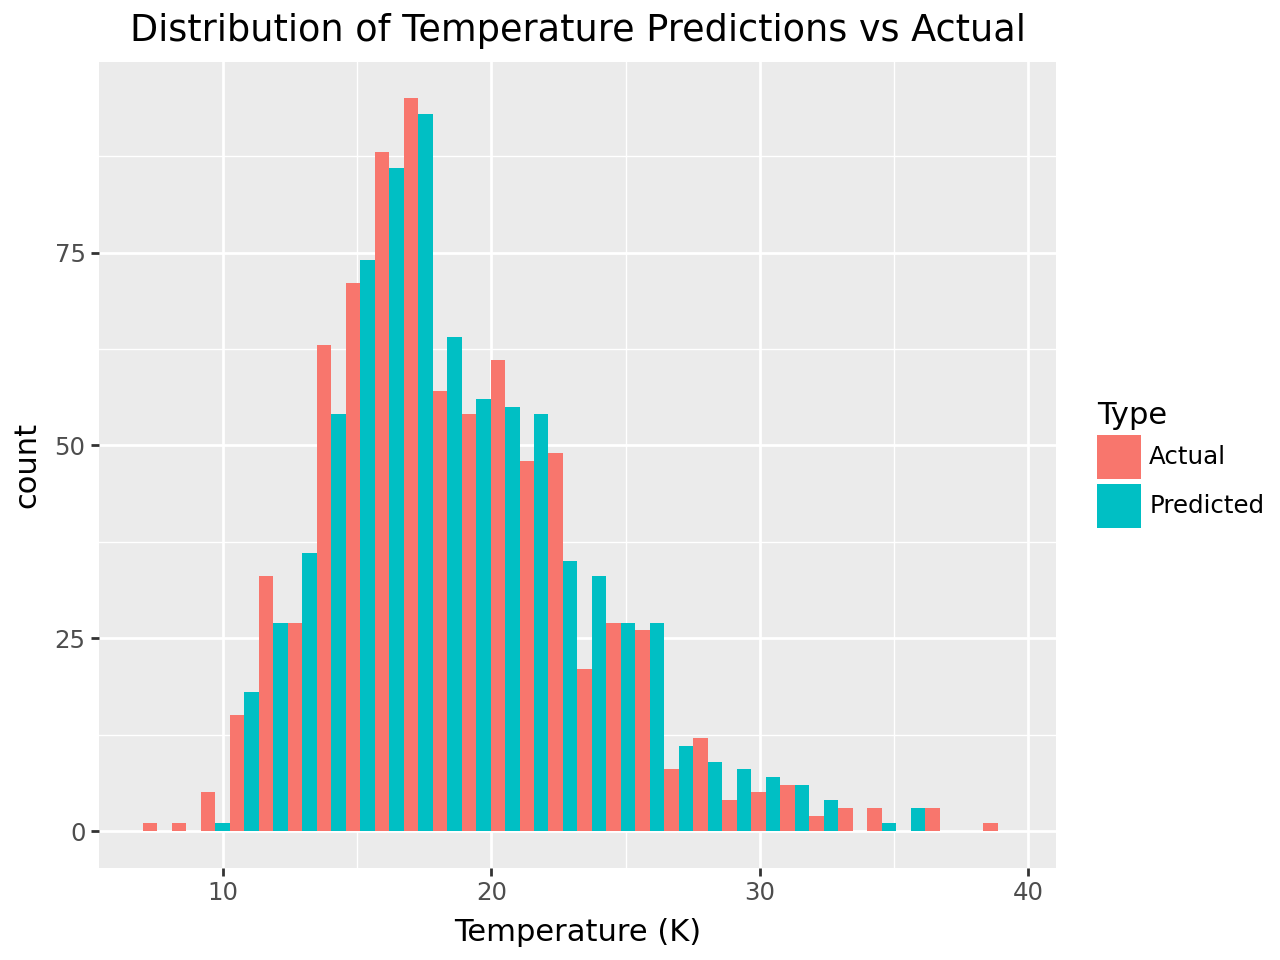

In [25]:
temp_predictions_df = temp_y_test.copy()
temp_predictions_df = pd.DataFrame(temp_predictions_df)
temp_predictions_df['y_preds'] = temp_y_preds
temp_predictions_df.head()

temp_melted = pd.melt(temp_predictions_df, value_vars=['TEMP', 'y_preds'], var_name='Variable', value_name='Value')

(
    ggplot(temp_melted, aes(x='Value', fill='Variable')) +
    geom_histogram(bins=30, position='dodge') +
    labs(title='Distribution of Temperature Predictions vs Actual', x='Temperature (K)') +
    scale_fill_discrete(labels=['Actual', 'Predicted'], name='Type')
)

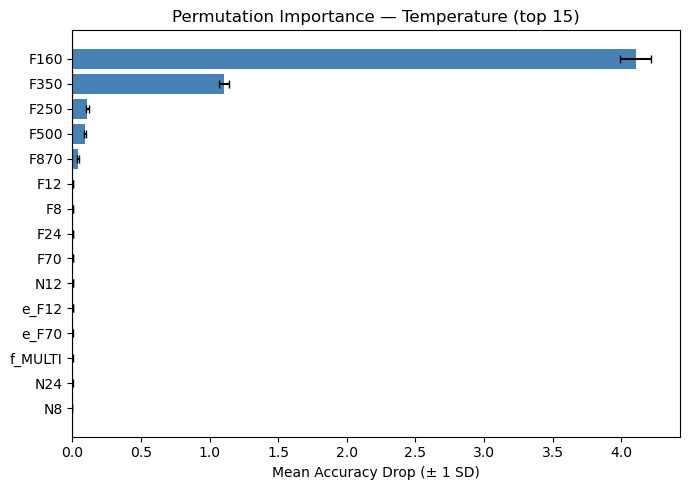

In [26]:
perm_temp = permutation_importance(
    best_temp_model, temp_X_test, temp_y_test,
    n_repeats=10, random_state=2026, n_jobs=-1
)

perm_temp_df = (pd.DataFrame({
    'feature': temp_X_test.columns,
    'mean': perm_temp.importances_mean,
    'std':  perm_temp.importances_std
}).sort_values('mean', ascending=False).head(15))

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(perm_temp_df['feature'][::-1], perm_temp_df['mean'][::-1],
        xerr=perm_temp_df['std'][::-1], color='steelblue', capsize=3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mean Accuracy Drop (± 1 SD)')
ax.set_title('Permutation Importance — Temperature (top 15)')
plt.tight_layout()
plt.show()

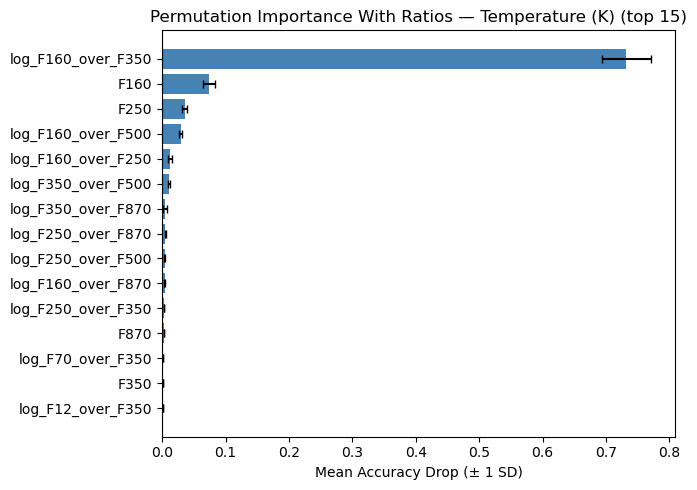

In [16]:
phot_for_perm = X.copy()
for top, bottom in itertools.combinations(flux_cols, 2):
    new_col_name = f"log_{top}_over_{bottom}"
    phot_for_perm[new_col_name] = np.log(phot_for_perm[top] / phot_for_perm[bottom])
perm_temp_X_train, perm_temp_X_test, perm_temp_y_train, perm_temp_y_test = train_test_split(phot_for_perm, y_temp, test_size = 0.2, random_state=2026)
perm_temp_pipe = Pipeline([
    ('impute', SimpleImputer()),
    ('scale', RobustScaler()),
    ('model', CatBoostRegressor(random_state=2026, verbose=0, thread_count=-1, loss_function='RMSE'))
])
if 'ratio' in temp_results['cat_params']:
    del temp_results['cat_params']['ratio']
perm_temp_pipe.set_params(**temp_results['cat_params'])
perm_temp_pipe.fit(perm_temp_X_train, perm_temp_y_train)
perm_temp_with_ratios = permutation_importance(
    perm_temp_pipe, perm_temp_X_test, perm_temp_y_test,
    n_repeats=10, random_state=2026, n_jobs=-1
)
perm_temp_ratios_df = (pd.DataFrame({
    'feature': perm_temp_X_test.columns,
    'mean': perm_temp_with_ratios.importances_mean,
    'std':  perm_temp_with_ratios.importances_std
}).sort_values('mean', ascending=False).head(15))

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(perm_temp_ratios_df['feature'][::-1], perm_temp_ratios_df['mean'][::-1],
        xerr=perm_temp_ratios_df['std'][::-1], color='steelblue', capsize=3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mean Accuracy Drop (± 1 SD)')
ax.set_title('Permutation Importance With Ratios — Temperature (K) (top 15)')
plt.tight_layout()
plt.show()

# Bolometric Temperature

In [ ]:
with open(here("models/full_models/6-20-26_best_skopt_models", "T_BOL_results.pkl"), 'rb') as file:
    tbol_results = pickle.load(file)

print(tbol_results['cat_CV'])
# print(tbol_results['xgb_CV'])
# print(tbol_results['rf_CV'])
# print(tbol_results['tree_CV'])
# print(tbol_results['svr_CV'])
print(tbol_results['cat_params'])

8.498187410666723
OrderedDict({'impute': 'passthrough', 'model__bagging_temperature': 4.285468582020602, 'model__border_count': 32, 'model__colsample_bylevel': 0.05, 'model__depth': 10, 'model__grow_policy': 'SymmetricTree', 'model__iterations': 2789, 'model__l2_leaf_reg': 0.004350520009068172, 'model__learning_rate': 0.005252738881489917, 'model__min_data_in_leaf': 100, 'model__random_strength': 0.032409400492328926, 'ratio': LogRatioGenerator(cols=['F8', 'F12', 'F24', 'F70', 'F160', 'F250', 'F350',
                        'F500', 'F870', 'F1100']), 'scale': RobustScaler()})
['YB', 'DIAM', 'MASS', 'L_BOL', 'LM', 'TEMP', 'LRATIO', 'T_BOL', 'SURF_DENS', 'F160', 'F250', 'F350', 'F500', 'F870', 'F1100', 'DIST', 'F8', 'e_F8', 'F12', 'e_F12', 'F24', 'e_F24', 'F70', 'e_F70', 'N8', 'N12', 'N24', 'N70', 'f_MULTI', 'f_CEXT']


In [26]:
phot_tbol = phot[phot['T_BOL'] <= 90]
y_tbol = phot_tbol['T_BOL']
phot_tbol_X = phot_tbol.drop(columns=remove_properties)

tbol_X_train, tbol_X_test, tbol_y_train, tbol_y_test = train_test_split(phot_tbol_X, y_tbol, test_size = 0.2, random_state=2026)

tbol_model_pipe = clone(model_pipe)
tbol_model = CatBoostRegressor(random_state=2026, verbose=0, thread_count=-1, loss_function='RMSE')
best_tbol_model = tbol_model_pipe.set_params(model=tbol_model)
best_tbol_model.set_params(**tbol_results['cat_params'])

best_tbol_model.fit(tbol_X_train, tbol_y_train)
tbol_y_preds = best_tbol_model.predict(tbol_X_test)
tbol_rmse = root_mean_squared_error(tbol_y_test, tbol_y_preds)
tbol_r2 = r2_score(tbol_y_test, tbol_y_preds)
print(f"Training set RMSE for tbol is {tbol_results['cat_CV']:.4f}.")
print(f"Test set RMSE for tbol is {tbol_rmse:.4f}.")
print("\n")
print(f"Test set r squared for tbol is {tbol_r2:.4f}.")

results["RESP"].append('T_BOL')
results['log'].append(False)
results['CV_score'].append(tbol_results['cat_CV'])
results['model_type'].append('Catboost')
results['test_score'].append(tbol_rmse)
results['test_r2'].append(tbol_r2)

Training set RMSE for tbol is 8.4982.
Test set RMSE for tbol is 7.1834.


Test set r squared for tbol is 0.5194.


In [30]:
# tbol_importances = best_tbol_model.named_steps['model'].feature_importances_
# tbol_imp_df = pd.DataFrame({
#     'Feature': best_tbol_model.named_steps['model'].feature_names_,
#     'Importance': tbol_importances
# }).sort_values(by='Importance', ascending=False)
# print(tbol_imp_df.head())
# tbol_imp_df['Feature'] = pd.Categorical(tbol_imp_df['Feature'], categories=tbol_imp_df['Feature'].unique())
# (
#     ggplot(tbol_imp_df.head(), aes(x='Feature', y='Importance')) +
#     geom_col()
# )

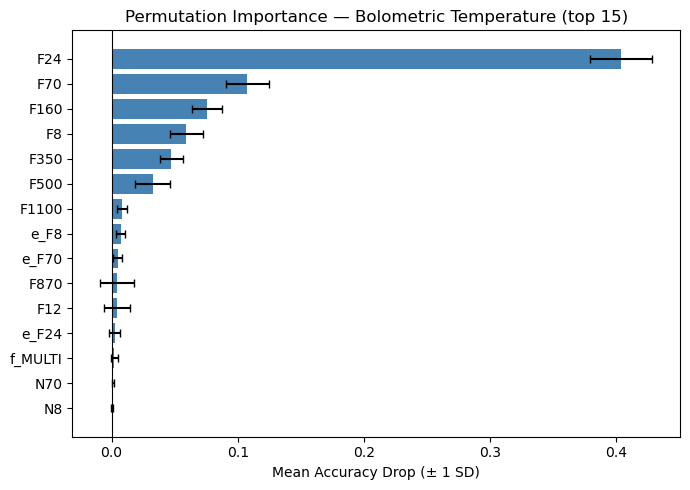

In [19]:
perm_tbol = permutation_importance(
    best_tbol_model, tbol_X_test, tbol_y_test,
    n_repeats=20, random_state=2026, n_jobs=-1
)

perm_tbol_df = (pd.DataFrame({
    'feature': tbol_X_test.columns,
    'mean': perm_tbol.importances_mean,
    'std':  perm_tbol.importances_std
}).sort_values('mean', ascending=False).head(15))

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(perm_tbol_df['feature'][::-1], perm_tbol_df['mean'][::-1],
        xerr=perm_tbol_df['std'][::-1], color='steelblue', capsize=3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mean Accuracy Drop (± 1 SD)')
ax.set_title('Permutation Importance — Bolometric Temperature (top 15)')
plt.tight_layout()
plt.show()

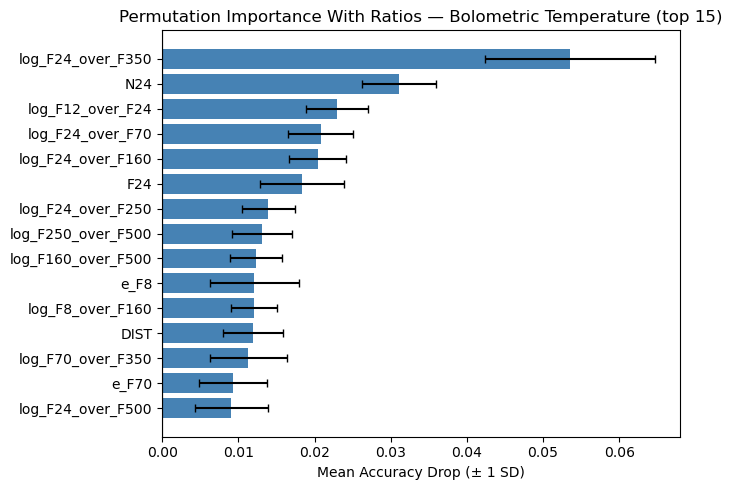

In [28]:
phot_for_perm = phot_tbol_X.copy()
for top, bottom in itertools.combinations(flux_cols, 2):
    new_col_name = f"log_{top}_over_{bottom}"
    phot_for_perm[new_col_name] = np.log(phot_for_perm[top] / phot_for_perm[bottom])
perm_tbol_X_train, perm_tbol_X_test, perm_tbol_y_train, perm_tbol_y_test = train_test_split(phot_for_perm, y_tbol, test_size = 0.2, random_state=2026)
perm_tbol_pipe = Pipeline([
    ('impute', SimpleImputer()),
    ('scale', RobustScaler()),
    ('model', CatBoostRegressor(random_state=2026, verbose=0, thread_count=-1, loss_function='RMSE'))
])
# if 'ratio' in tbol_results['cat_params']:
#     del tbol_results['cat_params']['ratio']
# perm_tbol_pipe.set_params(**tbol_results['cat_params'])
perm_tbol_pipe.fit(perm_tbol_X_train, perm_tbol_y_train)
perm_tbol_with_ratios = permutation_importance(
    perm_tbol_pipe, perm_tbol_X_test, perm_tbol_y_test,
    n_repeats=20, random_state=2026, n_jobs=-1
)
perm_tbol_ratios_df = (pd.DataFrame({
    'feature': perm_tbol_X_test.columns,
    'mean': perm_tbol_with_ratios.importances_mean,
    'std':  perm_tbol_with_ratios.importances_std
}).sort_values('mean', ascending=False).head(15))

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(perm_tbol_ratios_df['feature'][::-1], perm_tbol_ratios_df['mean'][::-1],
        xerr=perm_tbol_ratios_df['std'][::-1], color='steelblue', capsize=3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mean Accuracy Drop (± 1 SD)')
ax.set_title('Permutation Importance With Ratios — Bolometric Temperature (top 15)')
plt.tight_layout()
plt.show()

# Surface Density

In [ ]:
with open(here("models/full_models/6-20-26_best_skopt_models", "SURF_DENS_results.pkl"), 'rb') as file:
    dens_results = pickle.load(file)

print(dens_results['cat_log_CV'])
# print(dens_results['xgb_log_CV'])
# print(dens_results['rf_log_CV'])
# print(dens_results['tree_log_CV'])
# print(dens_results['svr_log_CV'])
print(dens_results['cat_log_params'])

0.5398405530357059
OrderedDict({'impute': 'passthrough', 'model__bagging_temperature': 7.9016733500457415, 'model__border_count': 101, 'model__colsample_bylevel': 0.7636241113654064, 'model__depth': 4, 'model__grow_policy': 'SymmetricTree', 'model__iterations': 2331, 'model__l2_leaf_reg': 0.033545353057906305, 'model__learning_rate': 0.03183351873243166, 'model__min_data_in_leaf': 82, 'model__random_strength': 10.0, 'ratio': RatioGenerator(cols=['F8', 'F12', 'F24', 'F70', 'F160', 'F250', 'F350', 'F500',
                     'F870', 'F1100']), 'scale': StandardScaler()})


In [30]:
y_log_dens = np.log(phot['SURF_DENS'])

dens_X_train, dens_X_test, dens_y_train, dens_y_test = train_test_split(X, y_log_dens, test_size = 0.2, random_state=2026)

dens_model_pipe = clone(model_pipe)
dens_model = CatBoostRegressor(random_state=2026, verbose=0, thread_count=-1, loss_function='RMSE')
best_dens_model = dens_model_pipe.set_params(model=dens_model)
best_dens_model.set_params(**dens_results['cat_log_params'])

best_dens_model.fit(dens_X_train, dens_y_train)
dens_y_preds = best_dens_model.predict(dens_X_test)
dens_rmse = root_mean_squared_error(dens_y_test, dens_y_preds)
dens_r2 = r2_score(dens_y_test, dens_y_preds)
print(f"Training set RMSE (log scale) for surface dens is {dens_results['cat_log_CV']:.4f}.")
print(f"Test set RMSE (log scale) for surface dens is {dens_rmse:.4f}.")
print("\n")
print(f"Test set r squared (log scale) for surface dens is {dens_r2:.4f}.")

results["RESP"].append('SURF_DENS')
results['log'].append(True)
results['CV_score'].append(dens_results['cat_log_CV'])
results['model_type'].append('Catboost')
results['test_score'].append(dens_rmse)
results['test_r2'].append(dens_r2)

Training set RMSE (log scale) for surface dens is 0.5398.
Test set RMSE (log scale) for surface dens is 0.5385.


Test set r squared (log scale) for surface dens is 0.8389.


In [35]:
# dens_importances = best_dens_model.named_steps['model'].feature_importances_
# dens_imp_df = pd.DataFrame({
#     'Feature': best_dens_model.named_steps['model'].feature_names_,
#     'Importance': dens_importances
# }).sort_values(by='Importance', ascending=False)
# print(dens_imp_df.head())
# dens_imp_df['Feature'] = pd.Categorical(dens_imp_df['Feature'], categories=dens_imp_df['Feature'].unique())
# (
#     ggplot(dens_imp_df.head(), aes(x='Feature', y='Importance')) +
#     geom_col()
# )

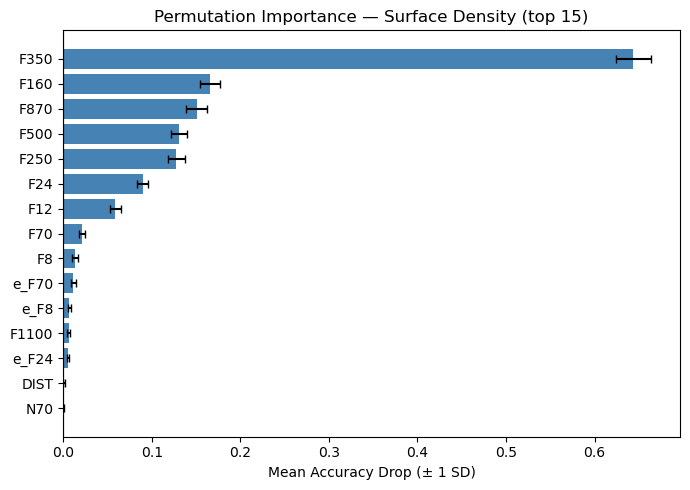

In [36]:
perm_dens = permutation_importance(
    best_dens_model, dens_X_test, dens_y_test,
    n_repeats=10, random_state=2026, n_jobs=-1
)

perm_dens_df = (pd.DataFrame({
    'feature': dens_X_test.columns,
    'mean': perm_dens.importances_mean,
    'std':  perm_dens.importances_std
}).sort_values('mean', ascending=False).head(15))

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(perm_dens_df['feature'][::-1], perm_dens_df['mean'][::-1],
        xerr=perm_dens_df['std'][::-1], color='steelblue', capsize=3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mean Accuracy Drop (± 1 SD)')
ax.set_title('Permutation Importance — Surface Density (top 15)')
plt.tight_layout()
plt.show()

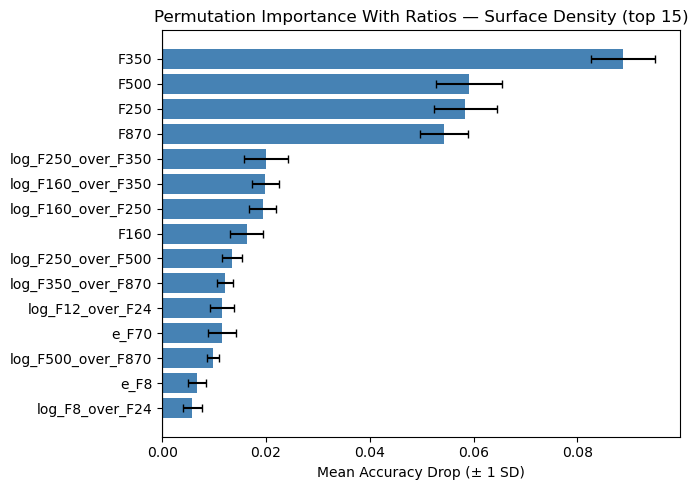

In [31]:
phot_for_perm = X.copy()
for top, bottom in itertools.combinations(flux_cols, 2):
    new_col_name = f"log_{top}_over_{bottom}"
    phot_for_perm[new_col_name] = np.log(phot_for_perm[top] / phot_for_perm[bottom])
perm_dens_X_train, perm_dens_X_test, perm_dens_y_train, perm_dens_y_test = train_test_split(phot_for_perm, y_log_dens, test_size = 0.2, random_state=2026)
perm_dens_pipe = Pipeline([
    ('impute', SimpleImputer()),
    ('scale', RobustScaler()),
    ('model', CatBoostRegressor(random_state=2026, verbose=0, thread_count=-1, loss_function='RMSE'))
])
if 'ratio' in dens_results['cat_log_params']:
    del dens_results['cat_log_params']['ratio']
perm_dens_pipe.set_params(**dens_results['cat_log_params'])
perm_dens_pipe.fit(perm_dens_X_train, perm_dens_y_train)
perm_dens_with_ratios = permutation_importance(
    perm_dens_pipe, perm_dens_X_test, perm_dens_y_test,
    n_repeats=10, random_state=2026, n_jobs=-1
)
perm_dens_ratios_df = (pd.DataFrame({
    'feature': perm_dens_X_test.columns,
    'mean': perm_dens_with_ratios.importances_mean,
    'std':  perm_dens_with_ratios.importances_std
}).sort_values('mean', ascending=False).head(15))

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(perm_dens_ratios_df['feature'][::-1], perm_dens_ratios_df['mean'][::-1],
        xerr=perm_dens_ratios_df['std'][::-1], color='steelblue', capsize=3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mean Accuracy Drop (± 1 SD)')
ax.set_title('Permutation Importance With Ratios — Surface Density (top 15)')
plt.tight_layout()
plt.show()

# Luminosity Mass Ratio

In [ ]:
with open(here("models/full_models/6-20-26_best_skopt_models", "LM_results.pkl"), 'rb') as file:
    lm_results = pickle.load(file)

print(lm_results['cat_log_CV'])
# print(lm_results['xgb_log_CV'])
# print(lm_results['rf_log_CV'])
# print(lm_results['tree_log_CV'])
# print(lm_results['svr_log_CV'])
print(lm_results['cat_log_params'])

0.46391148597139775
OrderedDict({'impute': 'passthrough', 'model__bagging_temperature': 10.0, 'model__border_count': 127, 'model__colsample_bylevel': 0.45648785611753745, 'model__depth': 7, 'model__grow_policy': 'Lossguide', 'model__iterations': 2927, 'model__l2_leaf_reg': 0.001, 'model__learning_rate': 0.005567005471994707, 'model__min_data_in_leaf': 1, 'model__random_strength': 10.0, 'ratio': LogRatioGenerator(cols=['F8', 'F12', 'F24', 'F70', 'F160', 'F250', 'F350',
                        'F500', 'F870', 'F1100']), 'scale': StandardScaler()})


In [33]:
y_log_lm = np.log(phot['LM'])

lm_X_train, lm_X_test, lm_y_train, lm_y_test = train_test_split(X, y_log_lm, test_size = 0.2, random_state=2026)

lm_model_pipe = clone(model_pipe)
lm_model = CatBoostRegressor(random_state=2026, verbose=0, thread_count=-1, loss_function='RMSE')
best_lm_model = lm_model_pipe.set_params(model=lm_model)
best_lm_model.set_params(**lm_results['cat_log_params'])

best_lm_model.fit(lm_X_train, lm_y_train)
lm_y_preds = best_lm_model.predict(lm_X_test)
lm_rmse = root_mean_squared_error(lm_y_test, lm_y_preds)
lm_r2 = r2_score(lm_y_test, lm_y_preds)
print(f"Training set RMSE (log scale) for lm is {lm_results['cat_log_CV']:.4f}.")
print(f"Test set RMSE (log scale) for lm is {lm_rmse:.4f}.")
print("\n")
print(f"Test set r squared (log scale) for lm is {lm_r2:.4f}.")

results["RESP"].append('LM')
results['log'].append(True)
results['CV_score'].append(lm_results['cat_log_CV'])
results['model_type'].append('Catboost')
results['test_score'].append(lm_rmse)
results['test_r2'].append(lm_r2)

Training set RMSE (log scale) for lm is 0.4639.
Test set RMSE (log scale) for lm is 0.4742.


Test set r squared (log scale) for lm is 0.8859.


In [40]:
# lm_importances = best_lm_model.named_steps['model'].feature_importances_
# lm_imp_df = pd.DataFrame({
#     'Feature': best_lm_model.named_steps['model'].feature_names_,
#     'Importance': lm_importances
# }).sort_values(by='Importance', ascending=False)
# print(lm_imp_df.head())
# lm_imp_df['Feature'] = pd.Categorical(lm_imp_df['Feature'], categories=lm_imp_df['Feature'].unique())
# (
#     ggplot(lm_imp_df.head(), aes(x='Feature', y='Importance')) +
#     geom_col()
# )

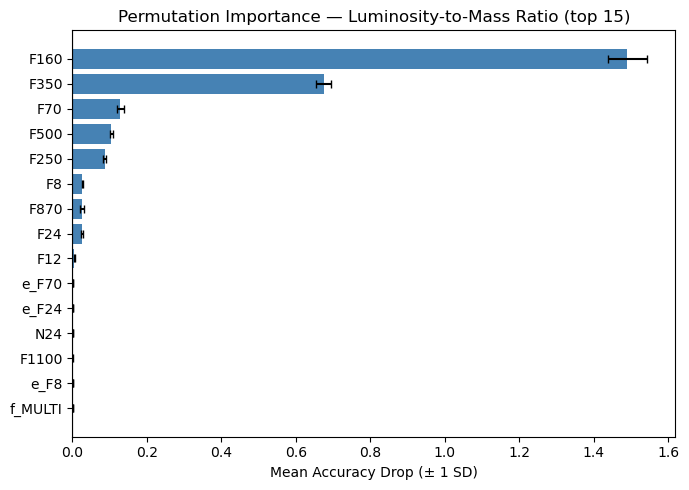

In [41]:
perm_lm = permutation_importance(
    best_lm_model, lm_X_test, lm_y_test,
    n_repeats=10, random_state=2026, n_jobs=-1
)

perm_lm_df = (pd.DataFrame({
    'feature': lm_X_test.columns,
    'mean': perm_lm.importances_mean,
    'std':  perm_lm.importances_std
}).sort_values('mean', ascending=False).head(15))

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(perm_lm_df['feature'][::-1], perm_lm_df['mean'][::-1],
        xerr=perm_lm_df['std'][::-1], color='steelblue', capsize=3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mean Accuracy Drop (± 1 SD)')
ax.set_title('Permutation Importance — Luminosity-to-Mass Ratio (top 15)')
plt.tight_layout()
plt.show()

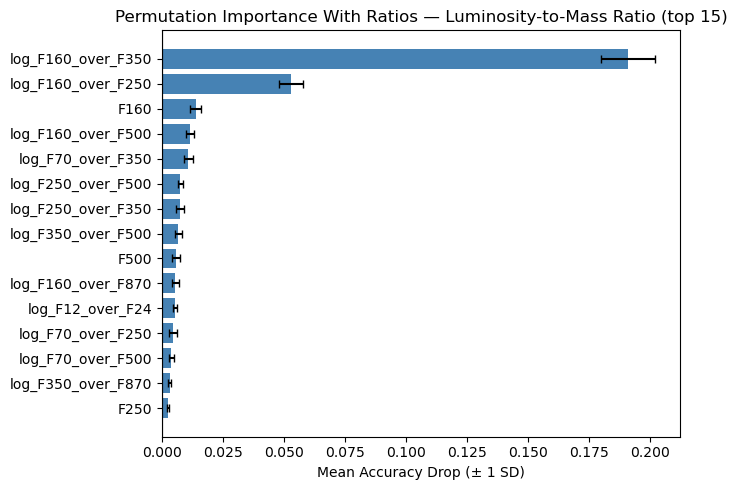

In [34]:
phot_for_perm = X.copy()
for top, bottom in itertools.combinations(flux_cols, 2):
    new_col_name = f"log_{top}_over_{bottom}"
    phot_for_perm[new_col_name] = np.log(phot_for_perm[top] / phot_for_perm[bottom])
perm_lm_X_train, perm_lm_X_test, perm_lm_y_train, perm_lm_y_test = train_test_split(phot_for_perm, y_log_lm, test_size = 0.2, random_state=2026)
perm_lm_pipe = Pipeline([
    ('impute', SimpleImputer()),
    ('scale', RobustScaler()),
    ('model', CatBoostRegressor(random_state=2026, verbose=0, thread_count=-1, loss_function='RMSE'))
])
if 'ratio' in lm_results['cat_log_params']:
    del lm_results['cat_log_params']['ratio']
perm_lm_pipe.set_params(**lm_results['cat_log_params'])
perm_lm_pipe.fit(perm_lm_X_train, perm_lm_y_train)
perm_lm_with_ratios = permutation_importance(
    perm_lm_pipe, perm_lm_X_test, perm_lm_y_test,
    n_repeats=10, random_state=2026, n_jobs=-1
)
perm_lm_ratios_df = (pd.DataFrame({
    'feature': perm_lm_X_test.columns,
    'mean': perm_lm_with_ratios.importances_mean,
    'std':  perm_lm_with_ratios.importances_std
}).sort_values('mean', ascending=False).head(15))

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(perm_lm_ratios_df['feature'][::-1], perm_lm_ratios_df['mean'][::-1],
        xerr=perm_lm_ratios_df['std'][::-1], color='steelblue', capsize=3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mean Accuracy Drop (± 1 SD)')
ax.set_title('Permutation Importance With Ratios — Luminosity-to-Mass Ratio (top 15)')
plt.tight_layout()
plt.show()

# Luminosity Ratio

In [ ]:
with open(here("models/full_models/6-20-26_best_skopt_models", "LRATIO_results.pkl"), 'rb') as file:
    lrat_results = pickle.load(file)

print(lrat_results['cat_log_CV'])
# print(lrat_results['xgb_log_CV'])
# print(lrat_results['rf_log_CV'])
# print(lrat_results['tree_log_CV'])
# print(lrat_results['svr_log_CV'])
print(lrat_results['cat_log_params'])

0.8750611991203785
OrderedDict({'impute': SimpleImputer(), 'model__bagging_temperature': 9.662514272906984, 'model__border_count': 130, 'model__colsample_bylevel': 0.9054504035128405, 'model__depth': 11, 'model__grow_policy': 'Lossguide', 'model__iterations': 2722, 'model__l2_leaf_reg': 25.67811050805595, 'model__learning_rate': 0.00526105272476867, 'model__min_data_in_leaf': 67, 'model__random_strength': 4.73396955620456, 'ratio': LogRatioGenerator(cols=['F8', 'F12', 'F24', 'F70', 'F160', 'F250', 'F350',
                        'F500', 'F870', 'F1100']), 'scale': RobustScaler()})


In [36]:
y_log_lrat = np.log(phot['LRATIO'])

lrat_X_train, lrat_X_test, lrat_y_train, lrat_y_test = train_test_split(X, y_log_lrat, test_size = 0.2, random_state=2026)

lrat_model_pipe = clone(model_pipe)
lrat_model = CatBoostRegressor(random_state=2026, verbose=0, thread_count=-1, loss_function='RMSE')
best_lrat_model = lrat_model_pipe.set_params(model=lrat_model)
best_lrat_model.set_params(**lrat_results['cat_log_params'])

best_lrat_model.fit(lrat_X_train, lrat_y_train)
lrat_y_preds = best_lrat_model.predict(lrat_X_test)
lrat_rmse = root_mean_squared_error(lrat_y_test, lrat_y_preds)
lrat_r2 = r2_score(lrat_y_test, lrat_y_preds)
print(f"Training set RMSE (log scale) for luminosity ratio is {lrat_results['cat_log_CV']:.4f}.")
print(f"Test set RMSE (log scale) for luminosity ratio is {lrat_rmse:.4f}.")
print("\n")
print(f"Test set r squared (log scale) for luminosity ratio is {lrat_r2:.4f}.")

results["RESP"].append('L_RATIO')
results['log'].append(True)
results['CV_score'].append(lrat_results['cat_log_CV'])
results['model_type'].append('Catboost')
results['test_score'].append(lrat_rmse)
results['test_r2'].append(lrat_r2)

Training set RMSE (log scale) for luminosity ratio is 0.8751.
Test set RMSE (log scale) for luminosity ratio is 0.8607.


Test set r squared (log scale) for luminosity ratio is 0.5035.


In [45]:
# lrat_importances = best_lrat_model.named_steps['model'].feature_importances_
# lrat_imp_df = pd.DataFrame({
#     'Feature': best_lrat_model.named_steps['model'].feature_names_,
#     'Importance': lrat_importances
# }).sort_values(by='Importance', ascending=False)
# print(lrat_imp_df.head())
# lrat_imp_df['Feature'] = pd.Categorical(lrat_imp_df['Feature'], categories=lrat_imp_df['Feature'].unique())
# (
#     ggplot(lrat_imp_df.head(), aes(x='Feature', y='Importance')) +
#     geom_col()
# )


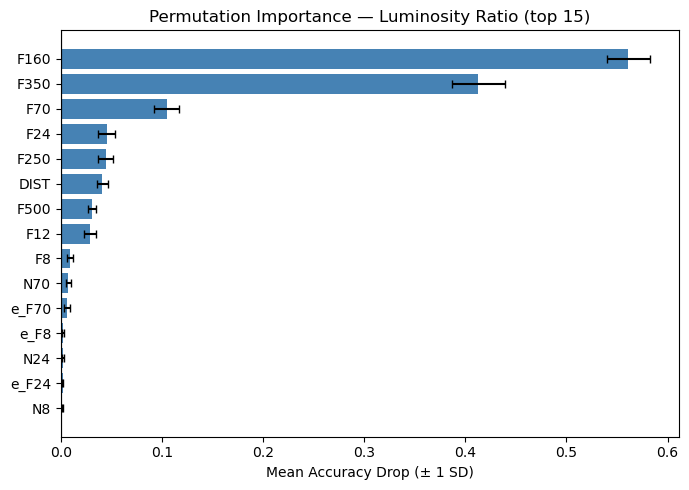

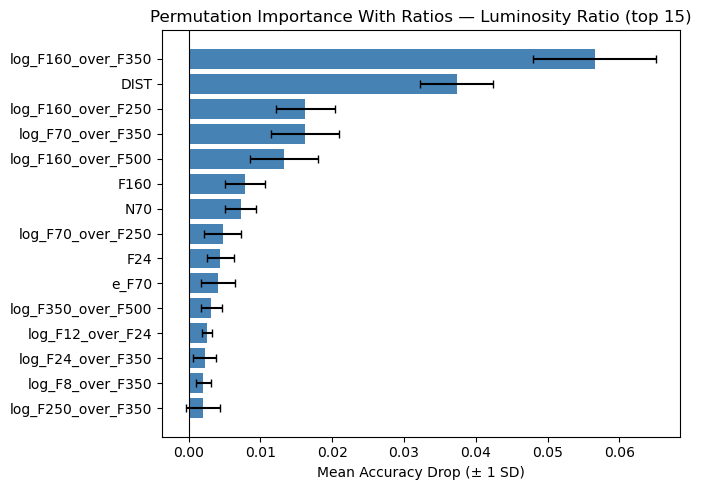

In [37]:
perm_lrat = permutation_importance(
    best_lrat_model, lrat_X_test, lrat_y_test,
    n_repeats=10, random_state=2026, n_jobs=-1
)

perm_lrat_df = (pd.DataFrame({
    'feature': lrat_X_test.columns,
    'mean': perm_lrat.importances_mean,
    'std':  perm_lrat.importances_std
}).sort_values('mean', ascending=False).head(15))

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(perm_lrat_df['feature'][::-1], perm_lrat_df['mean'][::-1],
        xerr=perm_lrat_df['std'][::-1], color='steelblue', capsize=3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mean Accuracy Drop (± 1 SD)')
ax.set_title('Permutation Importance — Luminosity Ratio (top 15)')
plt.tight_layout()

phot_for_perm = X.copy()
for top, bottom in itertools.combinations(flux_cols, 2):
    new_col_name = f"log_{top}_over_{bottom}"
    phot_for_perm[new_col_name] = np.log(phot_for_perm[top] / phot_for_perm[bottom])
perm_lrat_X_train, perm_lrat_X_test, perm_lrat_y_train, perm_lrat_y_test = train_test_split(phot_for_perm, y_log_lrat, test_size = 0.2, random_state=2026)
perm_lrat_pipe = Pipeline([
    ('impute', SimpleImputer()),
    ('scale', RobustScaler()),
    ('model', CatBoostRegressor(random_state=2026, verbose=0, thread_count=-1, loss_function='RMSE'))
])
if 'ratio' in lrat_results['cat_log_params']:
    del lrat_results['cat_log_params']['ratio']
perm_lrat_pipe.set_params(**lrat_results['cat_log_params'])
perm_lrat_pipe.fit(perm_lrat_X_train, perm_lrat_y_train)
perm_lrat_with_ratios = permutation_importance(
    perm_lrat_pipe, perm_lrat_X_test, perm_lrat_y_test,
    n_repeats=10, random_state=2026, n_jobs=-1
)
perm_lrat_ratios_df = (pd.DataFrame({
    'feature': perm_lrat_X_test.columns,
    'mean': perm_lrat_with_ratios.importances_mean,
    'std':  perm_lrat_with_ratios.importances_std
}).sort_values('mean', ascending=False).head(15))

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(perm_lrat_ratios_df['feature'][::-1], perm_lrat_ratios_df['mean'][::-1],
        xerr=perm_lrat_ratios_df['std'][::-1], color='steelblue', capsize=3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mean Accuracy Drop (± 1 SD)')
ax.set_title('Permutation Importance With Ratios — Luminosity Ratio (top 15)')
plt.tight_layout()
plt.show()

# Result Metrics condensed to csv

In [47]:
final_results_df = pd.DataFrame(results)
final_results_df.head()
final_results_df = final_results_df.round(4)

In [48]:
# only need to conduct once, to finalize result metrics
# final_results_df.to_csv(here('results_final.csv'), index=False)

# Final project: Predicting physical properties for the rest of the yellowballs

unfortunately impossible with these good models due to the lack of longer wavelengths due to source crossmatch unavailability